SURPRISAL ANALYSIS — BK21 SPRT Dataset

April 14, 2026

Models: GPT-2 / Gemma-270M / Gemma-12B

Regimes: Full Vocab (token) / NLTK Masked (token) / 17k Word-Level


In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import os
import re
import glob
from scipy.stats import pearsonr, spearmanr
from IPython.display import display, Markdown


PURPLE_DARK = "#2D1B4E"
PURPLE_MID = "#6B4C9A"
PURPLE_LIGHT = "#A78BDA"
PURPLE_PALE = "#D4C4ED"

BLUE_DARK = "#1B3A5C"
BLUE_MID = "#3A7CA5"
BLUE_LIGHT = "#7CB9D6"
BLUE_PALE = "#C4DFF0"

ACCENT_TEAL = "#2E8B8B"

COND_PALETTE = {"HC": BLUE_PALE, "MC": BLUE_MID, "LC": BLUE_DARK}
DIR_PALETTE = {"Uni": PURPLE_DARK, "Bi": BLUE_DARK}
VOCAB_PALETTE = {"Full": PURPLE_MID, "NLTK": BLUE_MID, "17k Word": ACCENT_TEAL}

UNI_COLOR = PURPLE_MID
BI_COLOR = BLUE_MID
HUMAN_COLOR = "#E07A5F"  

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFE",
    "axes.edgecolor": "#CCCCCC",
    "grid.color": "#E8E8F0",
    "font.family": "sans-serif",
})


In [28]:
results_registry = {
    # Token-level Full Vocab
    "GPT-2 [Token Full]": {
        "path": "data_output/full_vocab_model/bk21_with_gpt2.csv",
        "uni_col": "uni_surprisal", "bi_col": "bi_surprisal",
        "family": "Token Full", "base_model": "GPT-2",
    },
    "Gemma-270M [Token Full]": {
        "path": "data_output/full_vocab_model/bk21_with_gemma270m.csv",
        "uni_col": "uni_surprisal", "bi_col": "bi_surprisal",
        "family": "Token Full", "base_model": "Gemma-270M",
    },
    "Gemma-12B [Token Full]": {
        "path": "data_output/full_vocab_model/bk21_with_gemma12b.csv",
        "uni_col": "uni_surprisal", "bi_col": "bi_surprisal",
        "family": "Token Full", "base_model": "Gemma-12B",
    },
    # Token-level NLTK Masked
    "GPT-2 [Token NLTK]": {
        "path": "data_output/nltk_filtered_model/bk21_with_gpt2_nltk.csv",
        "uni_col": "uni_surprisal", "bi_col": "bi_surprisal",
        "family": "Token NLTK", "base_model": "GPT-2",
    },
    "Gemma-270M [Token NLTK]": {
        "path": "data_output/nltk_filtered_model/bk21_with_gemma270m_nltk.csv",
        "uni_col": "uni_surprisal", "bi_col": "bi_surprisal",
        "family": "Token NLTK", "base_model": "Gemma-270M",
    },
    "Gemma-12B [Token NLTK]": {
        "path": "data_output/nltk_filtered_model/bk21_with_gemma12b_nltk.csv",
        "uni_col": "uni_surprisal", "bi_col": "bi_surprisal",
        "family": "Token NLTK", "base_model": "Gemma-12B",
    },
    # Word-level 17k
    "GPT-2 [Word 17k]": {
        "path": "data_output/17k_nltk_filtered_model/gpt2_wordlevel_batched.csv",
        "uni_col": "uni_surprisal_word", "bi_col": "bi_surprisal_word",
        "family": "Word 17k", "base_model": "GPT-2",
    },
    "Gemma-270M [Word 17k]": {
        "path": "data_output/17k_nltk_filtered_model/google_gemma-3-270m_wordlevel_batched.csv",
        "uni_col": "uni_surprisal_word", "bi_col": "bi_surprisal_word",
        "family": "Word 17k", "base_model": "Gemma-270M",
    },
    "Gemma-12B [Word 17k]": {
        "path": "data_output/17k_nltk_filtered_model/google_gemma-3-12b-pt_wordlevel_batched.csv",
        "uni_col": "uni_surprisal_word", "bi_col": "bi_surprisal_word",
        "family": "Word 17k", "base_model": "Gemma-12B",
    },
}


def load_and_normalize(name, info):
    path = info["path"]
    if not os.path.exists(path):
        print(f"  [MISSING] {name}: {path}")
        return None

    df = pd.read_csv(path)

    # Normalize column names
    df["uni"] = df[info["uni_col"]]
    df["bi"] = df[info["bi_col"]]

    df["condition"] = pd.Categorical(
        df["condition"], categories=["HC", "MC", "LC"], ordered=True
    )

    # Find cloze column
    for cloze_candidate in [
        "cloze_surprisal", "cloze_surprisal_bits_nair_oh",
        "cloze_surprisal_bits_add1",
    ]:
        if cloze_candidate in df.columns:
            df["cloze"] = df[cloze_candidate]
            break

    df["_family"] = info["family"]
    df["_base_model"] = info["base_model"]
    return df

dfs = {}
for name, info in results_registry.items():
    result = load_and_normalize(name, info)
    if result is not None:
        dfs[name] = result

print(f"Loaded {len(dfs)} datasets:")
for k, v in dfs.items():
    print(f"  ✓ {k} ({len(v)} rows, family={v['_family'].iloc[0]})")

Loaded 9 datasets:
  ✓ GPT-2 [Token Full] (648 rows, family=Token Full)
  ✓ Gemma-270M [Token Full] (648 rows, family=Token Full)
  ✓ Gemma-12B [Token Full] (648 rows, family=Token Full)
  ✓ GPT-2 [Token NLTK] (648 rows, family=Token NLTK)
  ✓ Gemma-270M [Token NLTK] (648 rows, family=Token NLTK)
  ✓ Gemma-12B [Token NLTK] (648 rows, family=Token NLTK)
  ✓ GPT-2 [Word 17k] (648 rows, family=Word 17k)
  ✓ Gemma-270M [Word 17k] (648 rows, family=Word 17k)
  ✓ Gemma-12B [Word 17k] (648 rows, family=Word 17k)


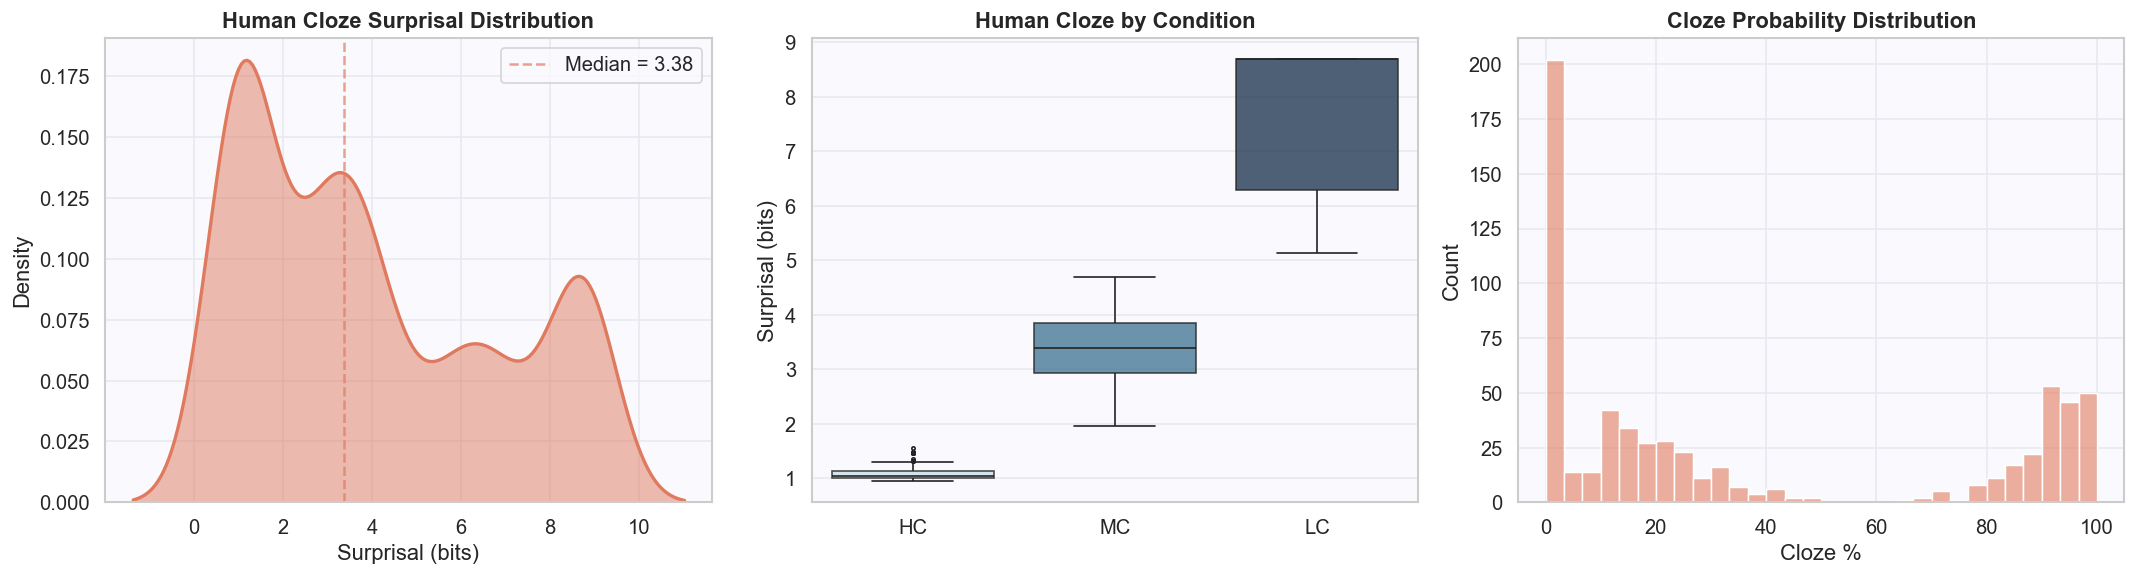


Human Cloze Surprisal by Condition:


C:\Users\PC\AppData\Local\Temp\ipykernel_3320\3855073678.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_df.groupby("condition")["cloze"]


,mean,std,min,max,count
condition,,,,,
HC,1.077,0.120,0.939,1.557,216
MC,3.348,0.619,1.961,4.690,216
LC,7.555,1.263,5.140,8.700,216


In [29]:
# Human Cloze Surprisal Overview

ref_key = list(dfs.keys())[0]
ref_df = dfs[ref_key]

if "cloze" in ref_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 2a. Distribution
    ax = axes[0]
    sns.kdeplot(ref_df["cloze"], ax=ax, fill=True, color=HUMAN_COLOR, alpha=0.5, linewidth=2)
    ax.set_title("Human Cloze Surprisal Distribution", fontweight="bold")
    ax.set_xlabel("Surprisal (bits)")
    ax.set_ylabel("Density")
    ax.axvline(ref_df["cloze"].median(), color=HUMAN_COLOR, ls="--", alpha=0.7,
               label=f"Median = {ref_df['cloze'].median():.2f}")
    ax.legend()

    # 2b. By condition
    ax = axes[1]
    sns.boxplot(
        data=ref_df, x="condition", y="cloze",
        palette=COND_PALETTE, hue="condition", legend=False, ax=ax,
        boxprops=dict(alpha=0.8), fliersize=2,
    )
    ax.set_title("Human Cloze by Condition", fontweight="bold")
    ax.set_ylabel("Surprisal (bits)")
    ax.set_xlabel("")

    # 2c. Cloze percent distribution
    ax = axes[2]
    if "cloze_percent" in ref_df.columns:
        cloze_pct = ref_df["cloze_percent"]
    elif "cloze_prob" in ref_df.columns:
        cloze_pct = ref_df["cloze_prob"] * 100
    else:
        cloze_pct = None

    if cloze_pct is not None:
        sns.histplot(cloze_pct, bins=30, color=HUMAN_COLOR, alpha=0.6, ax=ax, edgecolor="white")
        ax.set_title("Cloze Probability Distribution", fontweight="bold")
        ax.set_xlabel("Cloze %")
        ax.set_ylabel("Count")
    else:
        ax.text(0.5, 0.5, "No cloze_percent column", ha="center", va="center",
                transform=ax.transAxes)

    plt.tight_layout()
    plt.show()

    print("\nHuman Cloze Surprisal by Condition:")
    display(
        ref_df.groupby("condition")["cloze"]
        .agg(["mean", "std", "min", "max", "count"])
        .round(3)
    )

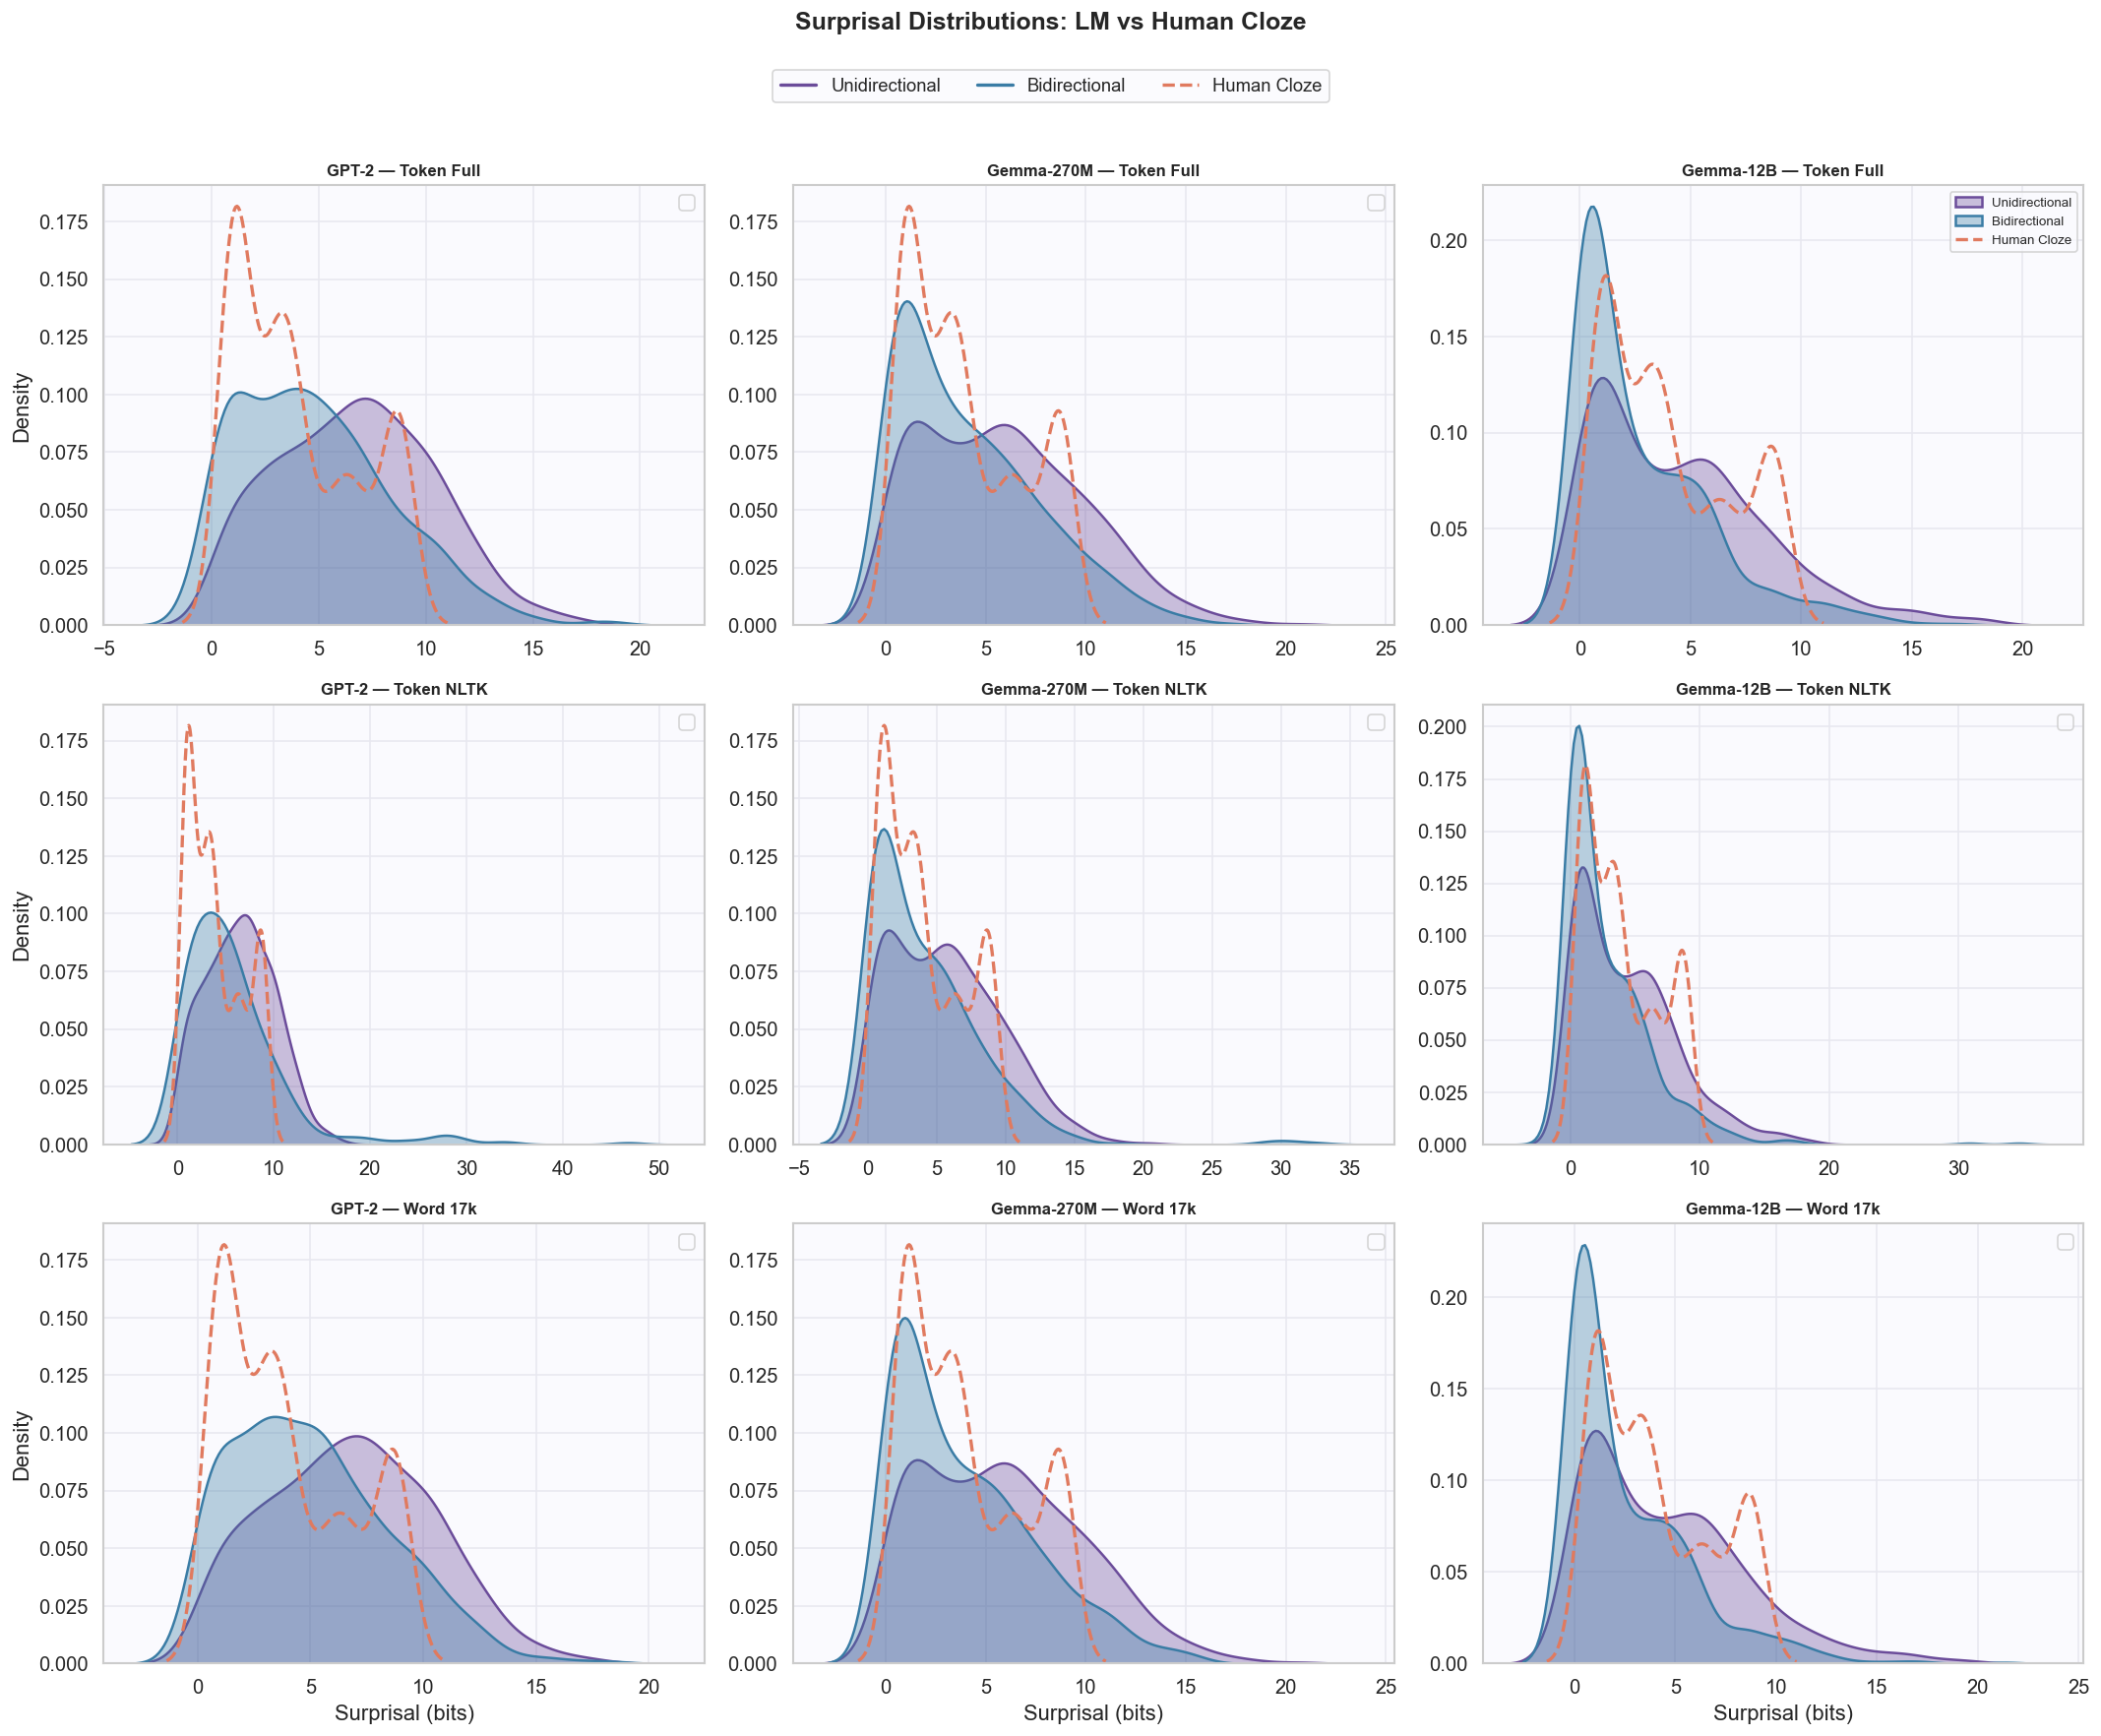

In [31]:
# Surprisal Distributions with Human Overlay

base_models = ["GPT-2", "Gemma-270M", "Gemma-12B"]
families = ["Token Full", "Token NLTK", "Word 17k"]

fig, axes = plt.subplots(len(families), len(base_models), figsize=(18, 14))

for row_idx, family in enumerate(families):
    for col_idx, base_model in enumerate(base_models):
        ax = axes[row_idx, col_idx]

        match_key = None
        for k, v in dfs.items():
            if v["_family"].iloc[0] == family and v["_base_model"].iloc[0] == base_model:
                match_key = k
                break

        if match_key:
            df = dfs[match_key]

            sns.kdeplot(df["uni"], ax=ax, fill=True, color=UNI_COLOR,
                        alpha=0.35, linewidth=1.5, label="Unidirectional")
            sns.kdeplot(df["bi"], ax=ax, fill=True, color=BI_COLOR,
                        alpha=0.35, linewidth=1.5, label="Bidirectional")

            if "cloze" in df.columns:
                sns.kdeplot(df["cloze"], ax=ax, fill=False, color=HUMAN_COLOR,
                            linewidth=2, linestyle="--", label="Human Cloze")

            ax.set_title(f"{base_model} — {family}", fontweight="bold", fontsize=10)
        else:
            ax.text(0.5, 0.5, "Missing", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12, color="gray")
            ax.set_title(f"{base_model} — {family}", fontweight="bold", fontsize=10)

        ax.set_xlabel("Surprisal (bits)" if row_idx == len(families) - 1 else "")
        ax.set_ylabel("Density" if col_idx == 0 else "")

        if row_idx == 0 and col_idx == len(base_models) - 1:
            ax.legend(fontsize=8, loc="upper right")
        else:
            ax.legend([], [])

handles = [
    Line2D([0], [0], color=UNI_COLOR, lw=2, label="Unidirectional"),
    Line2D([0], [0], color=BI_COLOR, lw=2, label="Bidirectional"),
    Line2D([0], [0], color=HUMAN_COLOR, lw=2, ls="--", label="Human Cloze"),
]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 1.02))

plt.suptitle("Surprisal Distributions: LM vs Human Cloze",
             y=1.05, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

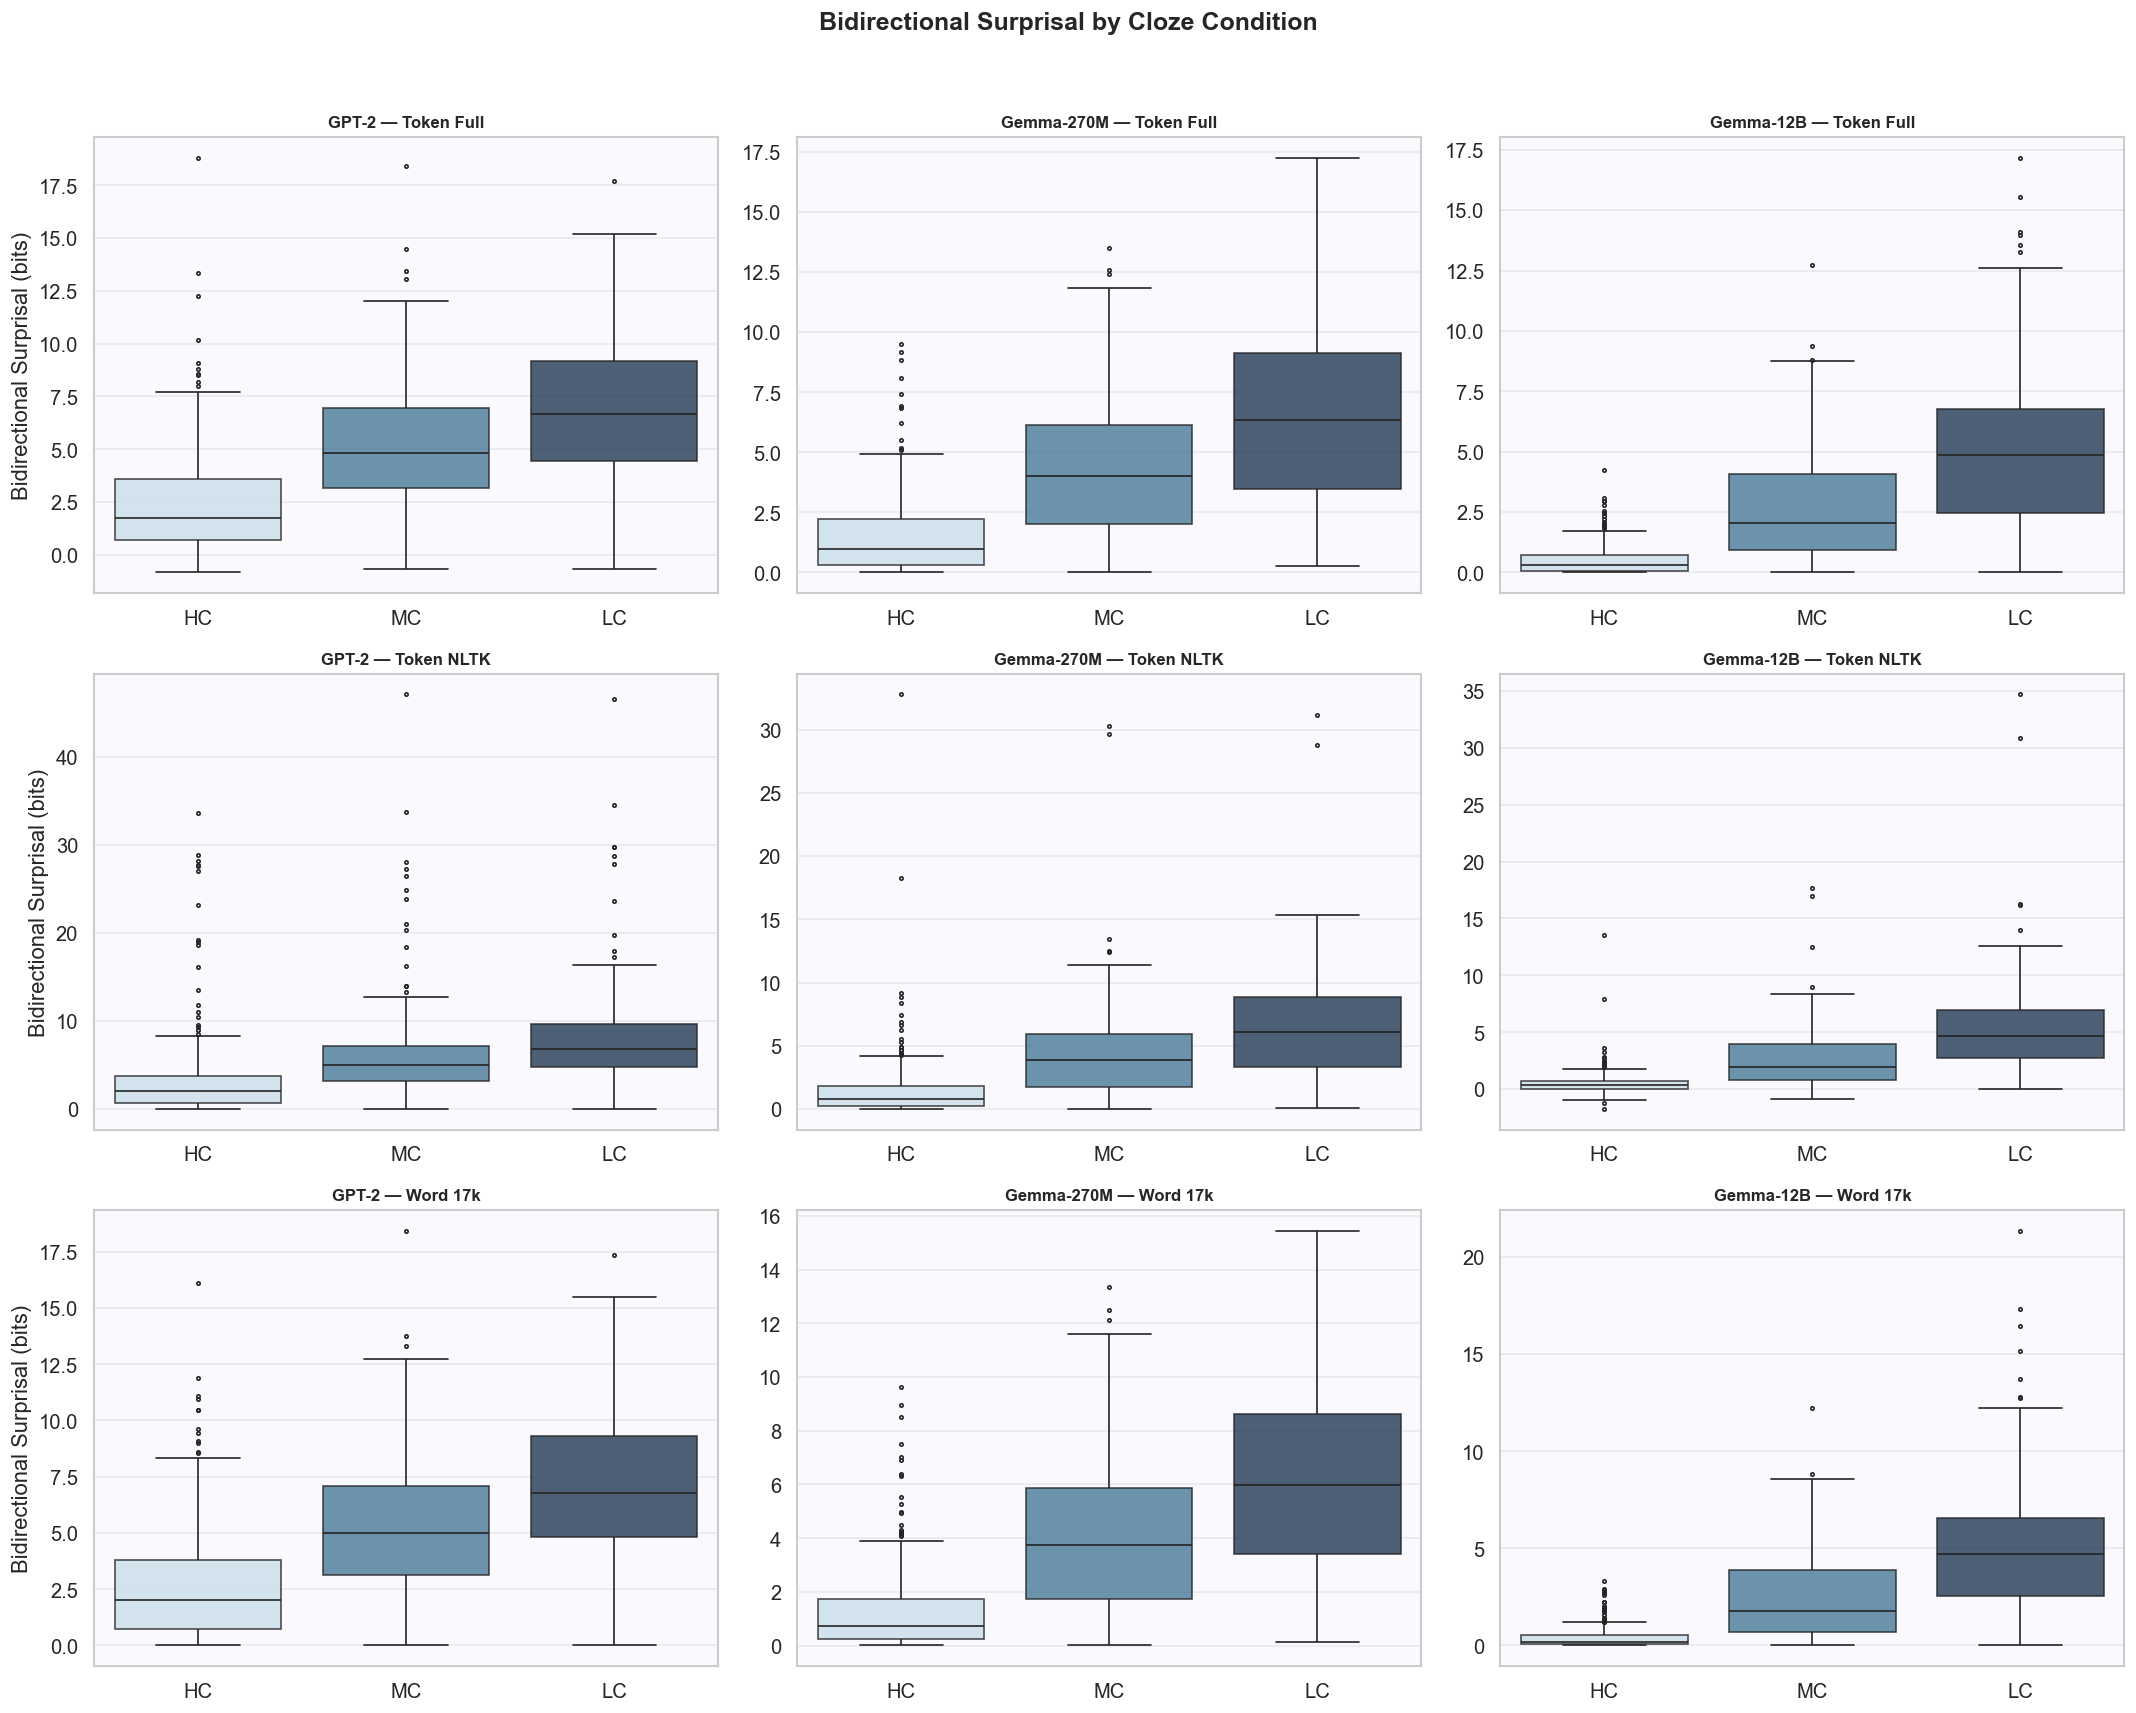

In [33]:
# Bidirectional Surprisal by Condition

fig, axes = plt.subplots(len(families), len(base_models), figsize=(18, 14))

for row_idx, family in enumerate(families):
    for col_idx, base_model in enumerate(base_models):
        ax = axes[row_idx, col_idx]

        match_key = None
        for k, v in dfs.items():
            if v["_family"].iloc[0] == family and v["_base_model"].iloc[0] == base_model:
                match_key = k
                break

        if match_key:
            df = dfs[match_key]
            sns.boxplot(
                data=df, x="condition", y="bi",
                palette=COND_PALETTE, hue="condition", legend=False, ax=ax,
                boxprops=dict(alpha=0.8), fliersize=2,
            )
            ax.set_title(f"{base_model} — {family}", fontweight="bold", fontsize=10)
        else:
            ax.set_title(f"{base_model} — {family} [MISSING]", fontsize=10)

        ax.set_ylabel("Bidirectional Surprisal (bits)" if col_idx == 0 else "")
        ax.set_xlabel("")

plt.suptitle("Bidirectional Surprisal by Cloze Condition",
             y=1.02, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

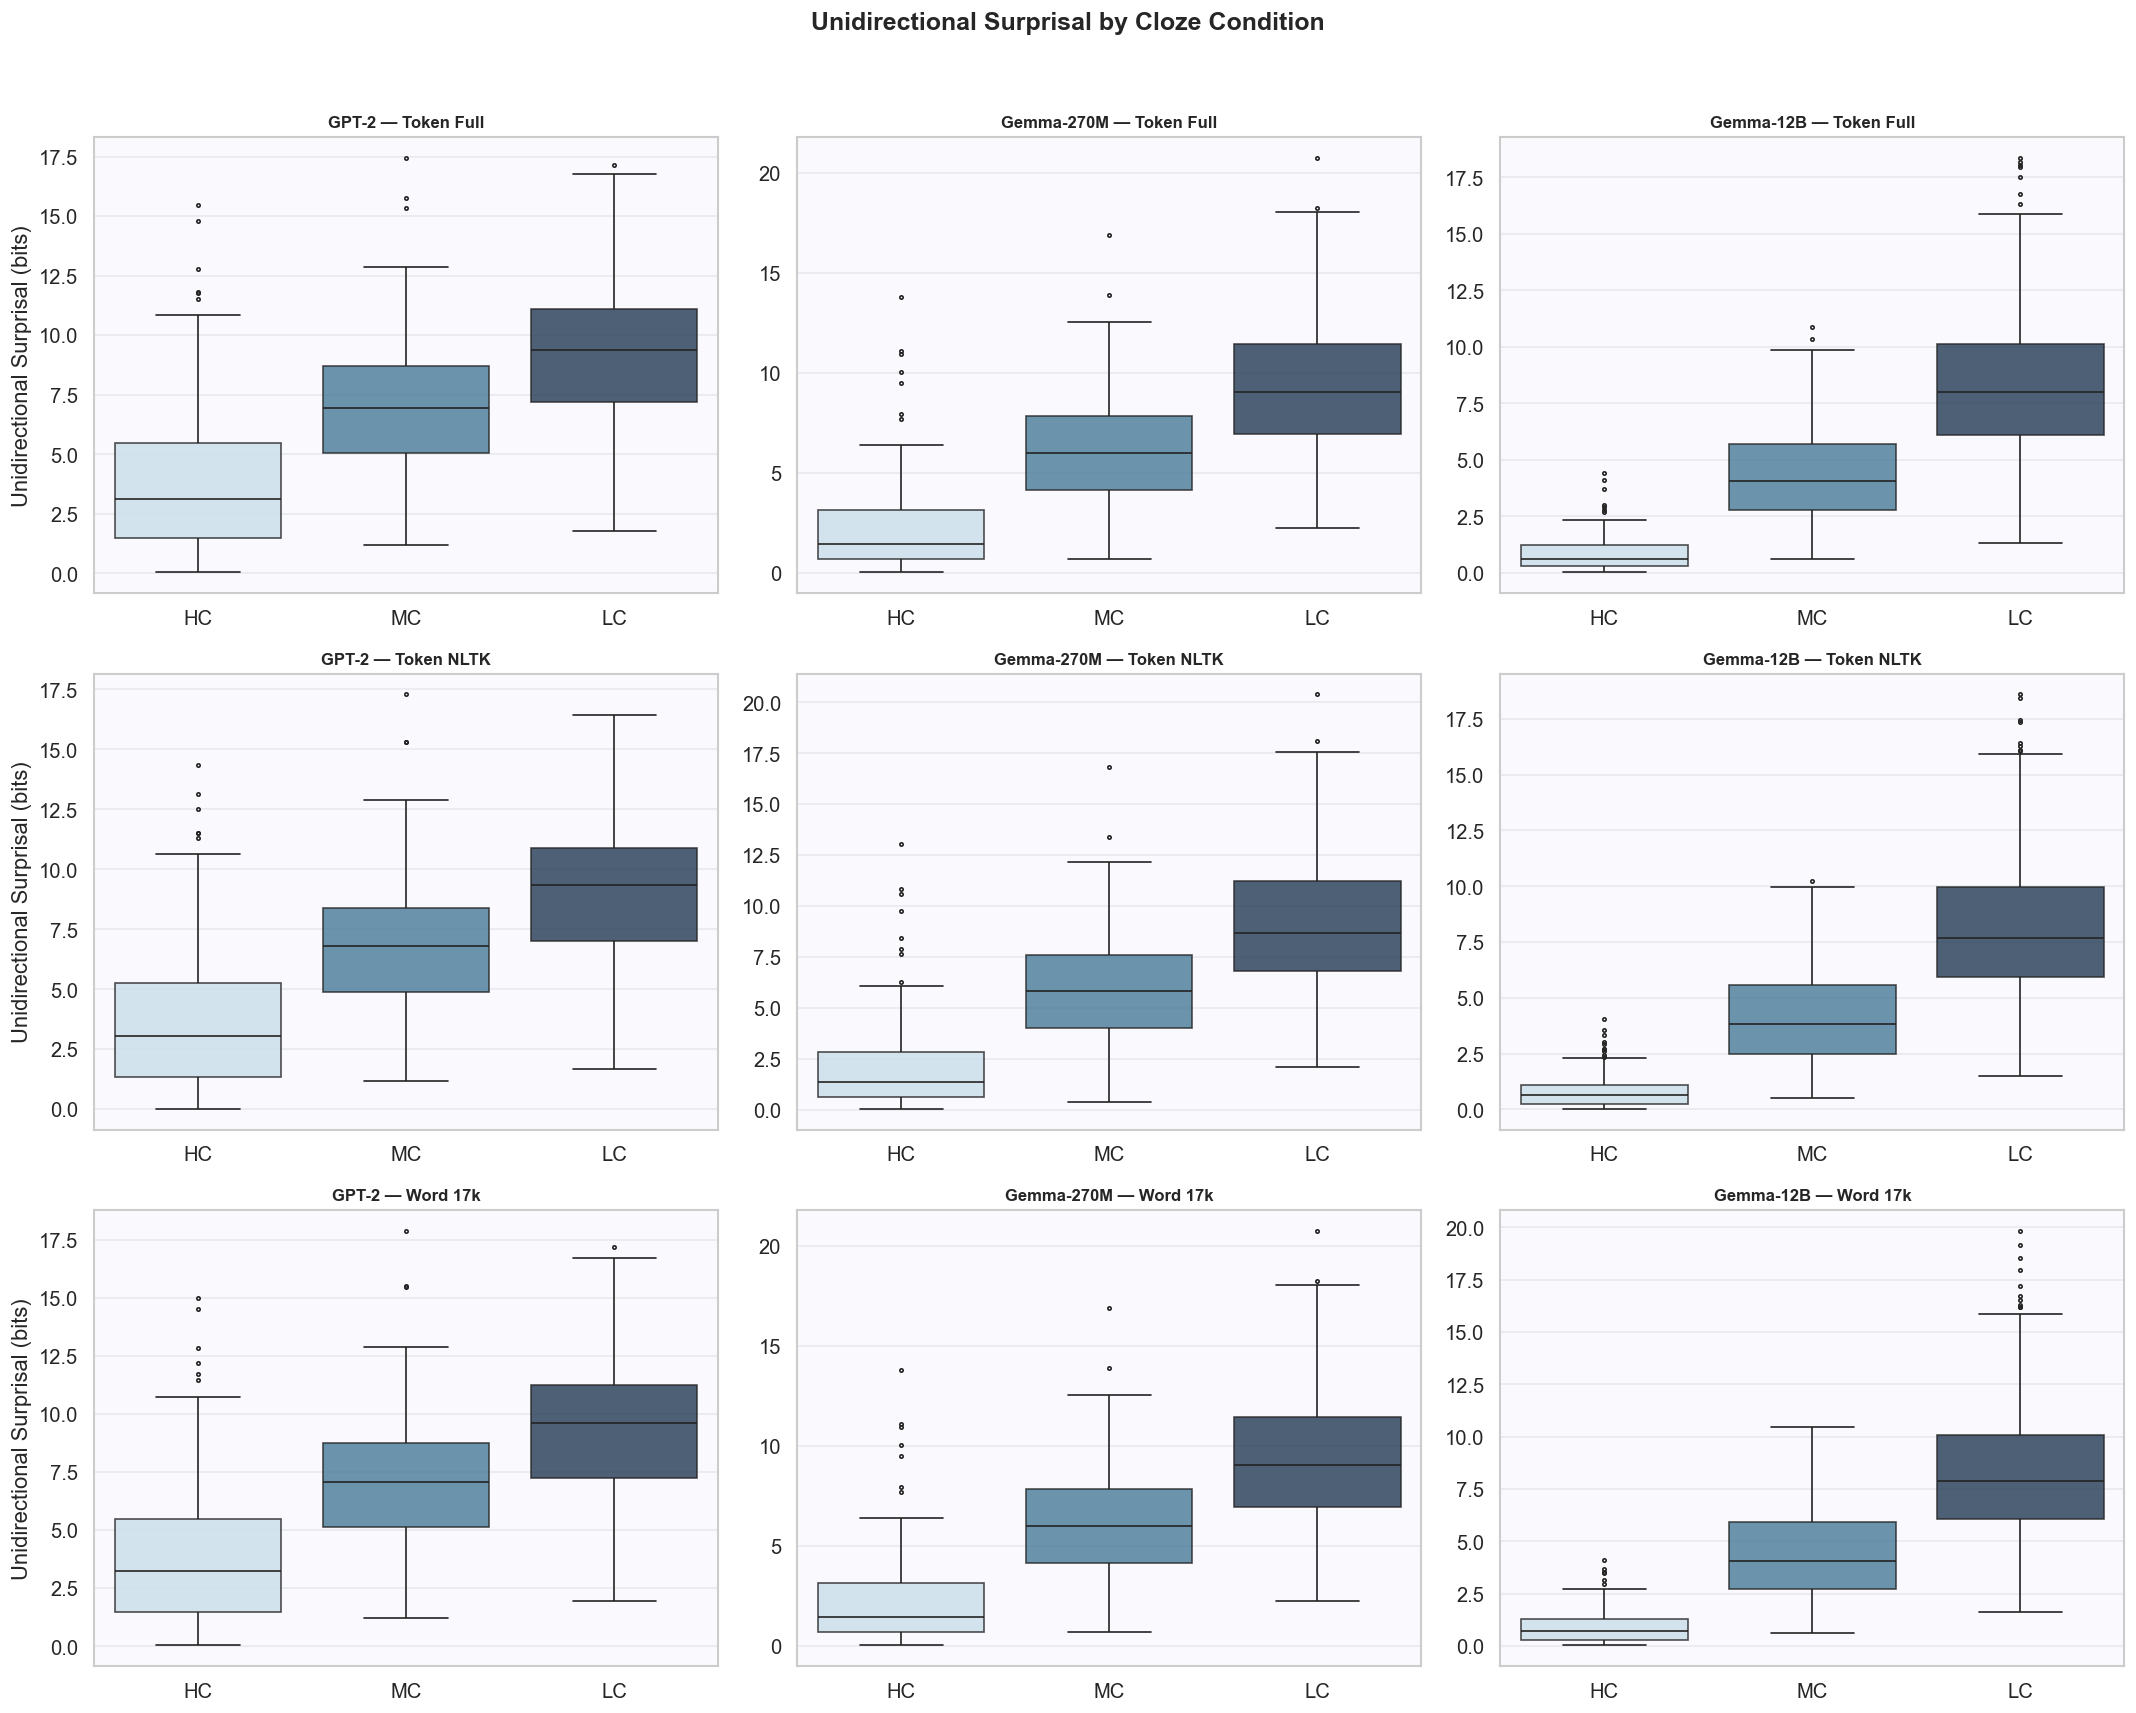

In [34]:
# Bidirectional Surprisal by Condition

fig, axes = plt.subplots(len(families), len(base_models), figsize=(18, 14))

for row_idx, family in enumerate(families):
    for col_idx, base_model in enumerate(base_models):
        ax = axes[row_idx, col_idx]

        match_key = None
        for k, v in dfs.items():
            if v["_family"].iloc[0] == family and v["_base_model"].iloc[0] == base_model:
                match_key = k
                break

        if match_key:
            df = dfs[match_key]
            sns.boxplot(
                data=df, x="condition", y="uni",
                palette=COND_PALETTE, hue="condition", legend=False, ax=ax,
                boxprops=dict(alpha=0.8), fliersize=2,
            )
            ax.set_title(f"{base_model} — {family}", fontweight="bold", fontsize=10)
        else:
            ax.set_title(f"{base_model} — {family} [MISSING]", fontsize=10)

        ax.set_ylabel("Unidirectional Surprisal (bits)" if col_idx == 0 else "")
        ax.set_xlabel("")

plt.suptitle("Unidirectional Surprisal by Cloze Condition",
             y=1.02, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [38]:
# Correlation with Human Cloze

corr_rows = []

for name, df in dfs.items():
    if "cloze" not in df.columns:
        continue
    valid = df.dropna(subset=["uni", "bi", "cloze"])
    if len(valid) < 10:
        continue

    r_uni_p, p_uni_p = pearsonr(valid["cloze"], valid["uni"])
    r_bi_p, p_bi_p = pearsonr(valid["cloze"], valid["bi"])
    r_uni_s, _ = spearmanr(valid["cloze"], valid["uni"])
    r_bi_s, _ = spearmanr(valid["cloze"], valid["bi"])

    corr_rows.append({
        "Model": name,
        "Family": df["_family"].iloc[0],
        "Base": df["_base_model"].iloc[0],
        "Uni Pearson": r_uni_p,
        "Bi Pearson": r_bi_p,
        "Uni Spearman": r_uni_s,
        "Bi Spearman": r_bi_s,
    })

corr_df = pd.DataFrame(corr_rows)

if not corr_df.empty:
    display(
        corr_df.set_index("Model")
        .style
        .background_gradient(cmap="PuBu", subset=["Uni Pearson", "Bi Pearson",
                                                    "Uni Spearman", "Bi Spearman"])
        .format("{:.4f}", subset=["Uni Pearson", "Bi Pearson",
                                   "Uni Spearman", "Bi Spearman"])
    )

,Family,Base,Uni Pearson,Bi Pearson,Uni Spearman,Bi Spearman
Model,,,,,,
GPT-2 [Token Full],Token Full,GPT-2,0.6196,0.4750,0.6436,0.5137
Gemma-270M [Token Full],Token Full,Gemma-270M,0.7428,0.5820,0.7723,0.6190
Gemma-12B [Token Full],Token Full,Gemma-12B,0.8345,0.6404,0.8802,0.6938
GPT-2 [Token NLTK],Token NLTK,GPT-2,0.6303,0.2927,0.6531,0.5183
Gemma-270M [Token NLTK],Token NLTK,Gemma-270M,0.7455,0.4934,0.7732,0.6240
Gemma-12B [Token NLTK],Token NLTK,Gemma-12B,0.8339,0.5764,0.8757,0.6816
GPT-2 [Word 17k],Word 17k,GPT-2,0.6256,0.5137,0.6503,0.5546
Gemma-270M [Word 17k],Word 17k,Gemma-270M,0.7428,0.5910,0.7723,0.6340
Gemma-12B [Word 17k],Word 17k,Gemma-12B,0.8288,0.6433,0.8759,0.7075


C:\Users\PC\AppData\Local\Temp\ipykernel_3320\2748348876.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
C:\Users\PC\AppData\Local\Temp\ipykernel_3320\2748348876.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
C:\Users\PC\AppData\Local\Temp\ipykernel_3320\2748348876.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


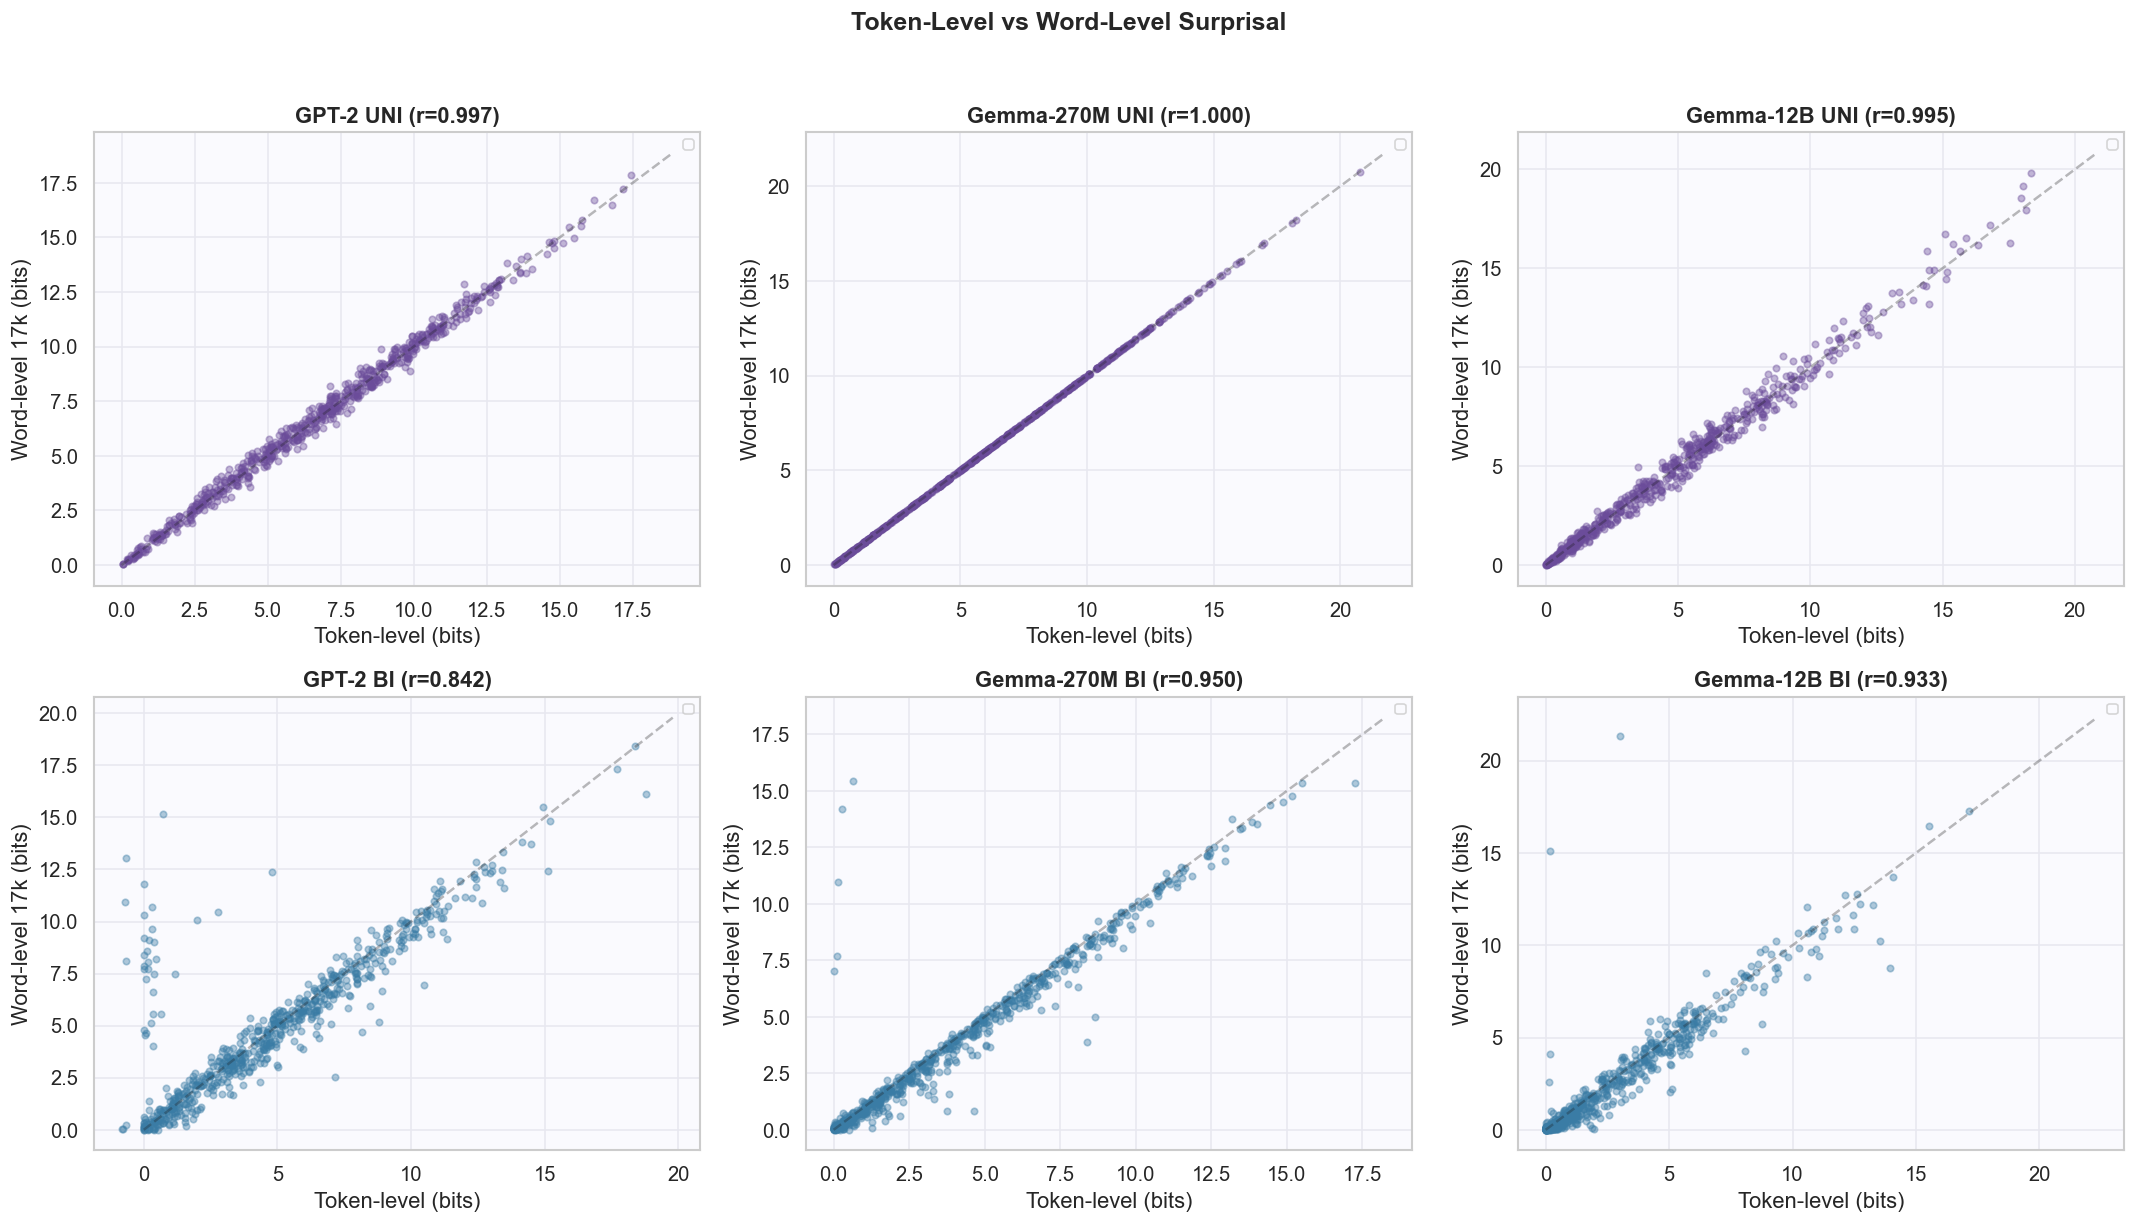

In [50]:
# Token-Level vs Word-Level Comparison

comparison_pairs = {
    "GPT-2": ("GPT-2 [Token Full]", "GPT-2 [Word 17k]"),
    "Gemma-270M": ("Gemma-270M [Token Full]", "Gemma-270M [Word 17k]"),
    "Gemma-12B": ("Gemma-12B [Token Full]", "Gemma-12B [Word 17k]"),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (base_name, (tok_key, wrd_key)) in enumerate(comparison_pairs.items()):
    if tok_key not in dfs or wrd_key not in dfs:
        continue

    df_tok = dfs[tok_key]
    df_wrd = dfs[wrd_key]

    merged = df_tok[["ITEM", "condition", "uni", "bi"]].merge(
        df_wrd[["ITEM", "condition", "uni", "bi"]],
        on=["ITEM", "condition"], suffixes=("_tok", "_wrd"),
    )

    for row_idx, (direction, col_tok, col_wrd) in enumerate([
        ("UNI", "uni_tok", "uni_wrd"),
        ("BI", "bi_tok", "bi_wrd"),
    ]):
        ax = axes[row_idx, col_idx]
        color = UNI_COLOR if direction == "UNI" else BI_COLOR

        ax.scatter(merged[col_tok], merged[col_wrd], alpha=0.4, s=15, c=color)

        lims = [0, max(merged[col_tok].max(), merged[col_wrd].max()) + 1]
        ax.plot(lims, lims, "k--", alpha=0.3)

        r, _ = pearsonr(merged[col_tok], merged[col_wrd])
        ax.set_title(f"{base_name} {direction} (r={r:.3f})", fontweight="bold")
        ax.set_xlabel("Token-level (bits)")
        ax.set_ylabel("Word-level 17k (bits)")
        ax.legend(fontsize=8)

plt.suptitle("Token-Level vs Word-Level Surprisal",
             y=1.02, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [40]:
# Information Gain: Bi vs Uni

print("Direction Check: % items where Bi > Uni")
print("=" * 60)
info_rows = []
for name, df in dfs.items():
    pct_bi_gt_uni = (df["bi"] > df["uni"]).mean()
    mean_gain = (df["uni"] - df["bi"]).mean()
    info_rows.append({
        "Model": name,
        "Family": df["_family"].iloc[0],
        "% Bi > Uni": f"{pct_bi_gt_uni:.1%}",
        "Mean Info Gain (Uni-Bi)": f"{mean_gain:.3f}",
    })
display(pd.DataFrame(info_rows).set_index("Model"))

Direction Check: % items where Bi > Uni


,Family,% Bi > Uni,Mean Info Gain (Uni-Bi)
Model,,,
GPT-2 [Token Full],Token Full,20.2%,1.867
Gemma-270M [Token Full],Token Full,21.1%,1.733
Gemma-12B [Token Full],Token Full,16.8%,1.760
GPT-2 [Token NLTK],Token NLTK,20.5%,0.634
Gemma-270M [Token NLTK],Token NLTK,20.5%,1.480
Gemma-12B [Token NLTK],Token NLTK,20.4%,1.565
GPT-2 [Word 17k],Word 17k,14.4%,1.736
Gemma-270M [Word 17k],Word 17k,17.1%,1.903
Gemma-12B [Word 17k],Word 17k,13.7%,1.948


In [41]:
# LME Regression Results — Parsed from R Output
from utils import parse_lme_files

df_aic, df_improve, df_fixed = parse_lme_files()

print(f"Parsed: {len(df_aic)} AIC records, {len(df_improve)} improvement tests, "
      f"{len(df_fixed)} fixed effects")

Parsed: 18 AIC records, 36 improvement tests, 18 fixed effects


### AIC Values (Lower = Better Fit)

Condition,Bi (17k Word),Bi (Full),Bi (NLTK),Uni (17k Word),Uni (Full),Uni (NLTK)
Model_Base,,,,,,
GPT-2,10416.300000,10417.100000,10418.900000,10401.600000,10401.600000,10402.000000
Gemma-12B,10416.400000,10412.200000,10417.300000,10397.300000,10396.800000,10399.400000
Gemma-270M,10416.600000,10415.900000,10415.500000,10403.600000,10403.600000,10404.400000


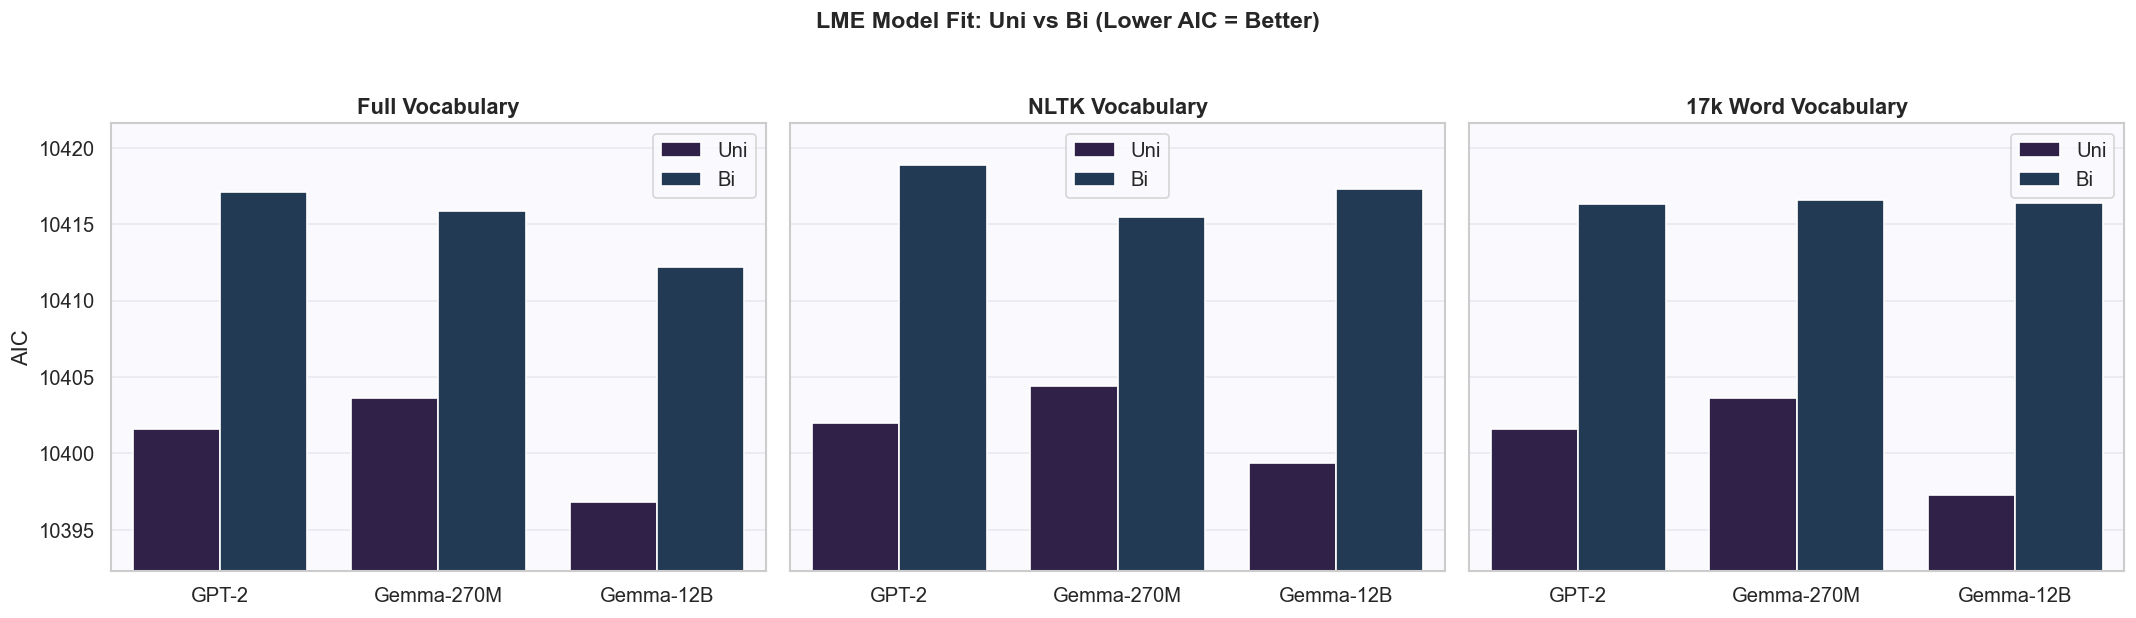

In [42]:
# AIC Comparison

if not df_aic.empty:
    df_aic[["Direction", "Vocab"]] = df_aic["Condition"].str.extract(r"(Uni|Bi) \((.*?)\)")

    display(Markdown("### AIC Values (Lower = Better Fit)"))
    pivot_aic = df_aic.pivot_table(
        index="Model_Base", columns="Condition", values="AIC"
    ).round(1)
    display(pivot_aic.style.background_gradient(cmap="PuBu_r", axis=None))

    # AIC plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    vocab_types = ["Full", "NLTK", "17k Word"]

    for i, vocab in enumerate(vocab_types):
        ax = axes[i]
        subset = df_aic[df_aic["Vocab"] == vocab]

        if not subset.empty:
            sns.barplot(
                data=subset, x="Model_Base", y="AIC", hue="Direction",
                palette=DIR_PALETTE, order=base_models, ax=ax,
            )
            ax.set_ylim(subset["AIC"].min() - 5, subset["AIC"].max() + 5)

        ax.set_title(f"{vocab} Vocabulary", fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("AIC" if i == 0 else "")
        ax.legend(title="")

    plt.suptitle("LME Model Fit: Uni vs Bi (Lower AIC = Better)",
                 y=1.03, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

### Model Improvement Tests

**Does LM surprisal improve over lexical baseline?**

C:\Users\PC\AppData\Local\Temp\ipykernel_3320\344494141.py:14: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .style.applymap(


,Model_Base,Condition,Chisq,p_value,Significant
0,GPT-2,Bi (17k Word),26.413000,***,True
1,GPT-2,Bi (Full),25.568000,***,True
2,GPT-2,Bi (NLTK),23.794000,***,True
3,GPT-2,Uni (17k Word),41.098000,***,True
4,GPT-2,Uni (Full),41.138000,***,True
5,GPT-2,Uni (NLTK),40.703000,***,True
6,Gemma-12B,Bi (17k Word),26.310000,***,True
7,Gemma-12B,Bi (Full),30.504000,***,True
8,Gemma-12B,Bi (NLTK),25.416000,***,True
9,Gemma-12B,Uni (17k Word),45.382000,***,True


**Does LM explain variance BEYOND human cloze?**

C:\Users\PC\AppData\Local\Temp\ipykernel_3320\344494141.py:28: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .style.applymap(


,Model_Base,Condition,Chisq,p_value,Significant
0,GPT-2,Bi (17k Word),1.047500,0.3061,False
1,GPT-2,Bi (Full),1.405900,0.2357,False
2,GPT-2,Bi (NLTK),1.600500,0.2058,False
3,GPT-2,Uni (17k Word),6.203400,*,True
4,GPT-2,Uni (Full),6.342100,*,True
5,GPT-2,Uni (NLTK),5.916500,*,True
6,Gemma-12B,Bi (17k Word),0.405200,0.5244,False
7,Gemma-12B,Bi (Full),1.364800,0.2427,False
8,Gemma-12B,Bi (NLTK),0.350900,0.5536,False
9,Gemma-12B,Uni (17k Word),6.133000,*,True


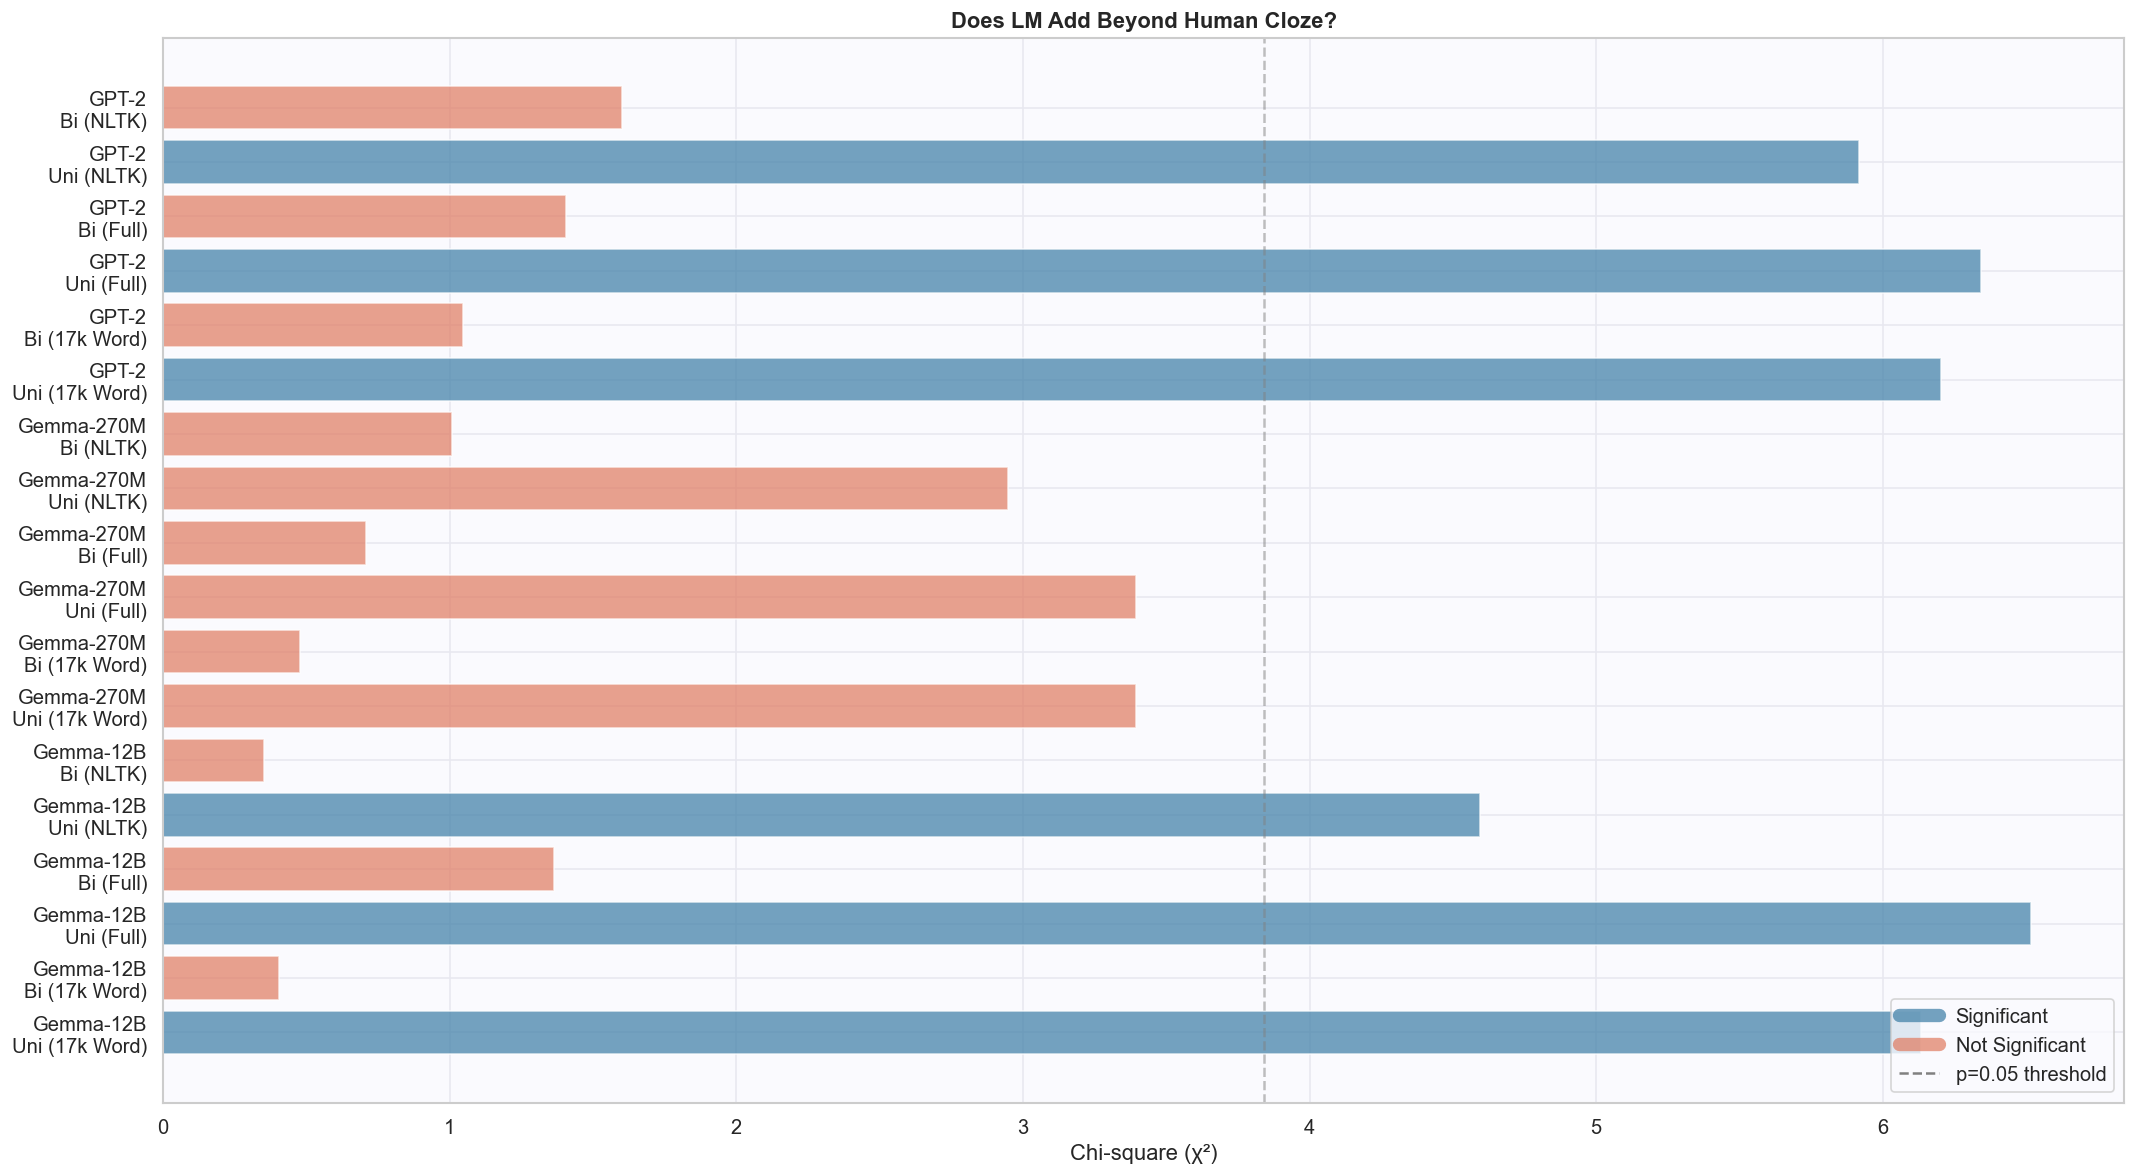

In [46]:
# Does LM Improve Over Baseline? (Human-Relevant)

if not df_improve.empty:
    display(Markdown("### Model Improvement Tests"))

    # Baseline improvement
    baseline_df = df_improve[df_improve["Test"] == "vs Baseline"].copy()
    if not baseline_df.empty:
        display(Markdown("**Does LM surprisal improve over lexical baseline?**"))
        display(
            baseline_df[["Model_Base", "Condition", "Chisq", "p_value", "Significant"]]
            .sort_values(["Model_Base", "Condition"])
            .reset_index(drop=True)
            .style.applymap(
                lambda v: "background-color: #D4C4ED" if v else "",
                subset=["Significant"]
            )
        )

    # Beyond cloze
    cloze_df = df_improve[df_improve["Test"] == "Beyond Cloze"].copy()
    if not cloze_df.empty:
        display(Markdown("**Does LM explain variance BEYOND human cloze?**"))
        display(
            cloze_df[["Model_Base", "Condition", "Chisq", "p_value", "Significant"]]
            .sort_values(["Model_Base", "Condition"])
            .reset_index(drop=True)
            .style.applymap(
                lambda v: "background-color: #C4DFF0" if v else "background-color: #FFE0D0",
                subset=["Significant"]
            )
        )

        # Visual summary
        fig, ax = plt.subplots(figsize=(18, 10))
        cloze_plot = cloze_df.copy()
        cloze_plot["label"] = cloze_plot["Model_Base"] + "\n" + cloze_plot["Condition"]
        cloze_plot["color"] = cloze_plot["Significant"].map(
            {True: BLUE_MID, False: HUMAN_COLOR}
        )

        bars = ax.barh(
            cloze_plot["label"], cloze_plot["Chisq"],
            color=cloze_plot["color"], alpha=0.7, edgecolor="white",
        )
        ax.axvline(3.84, color="gray", ls="--", alpha=0.5, label="χ²=3.84 (p=0.05)")
        ax.set_xlabel("Chi-square (χ²)")
        ax.set_title("Does LM Add Beyond Human Cloze?", fontweight="bold")

        legend_elements = [
            Line2D([0], [0], color=BLUE_MID, lw=8, alpha=0.7, label="Significant"),
            Line2D([0], [0], color=HUMAN_COLOR, lw=8, alpha=0.7, label="Not Significant"),
            Line2D([0], [0], color="gray", ls="--", label="p=0.05 threshold"),
        ]
        ax.legend(handles=legend_elements, loc="lower right")

        plt.tight_layout()
        plt.show()

### Surprisal Fixed Effect Sizes

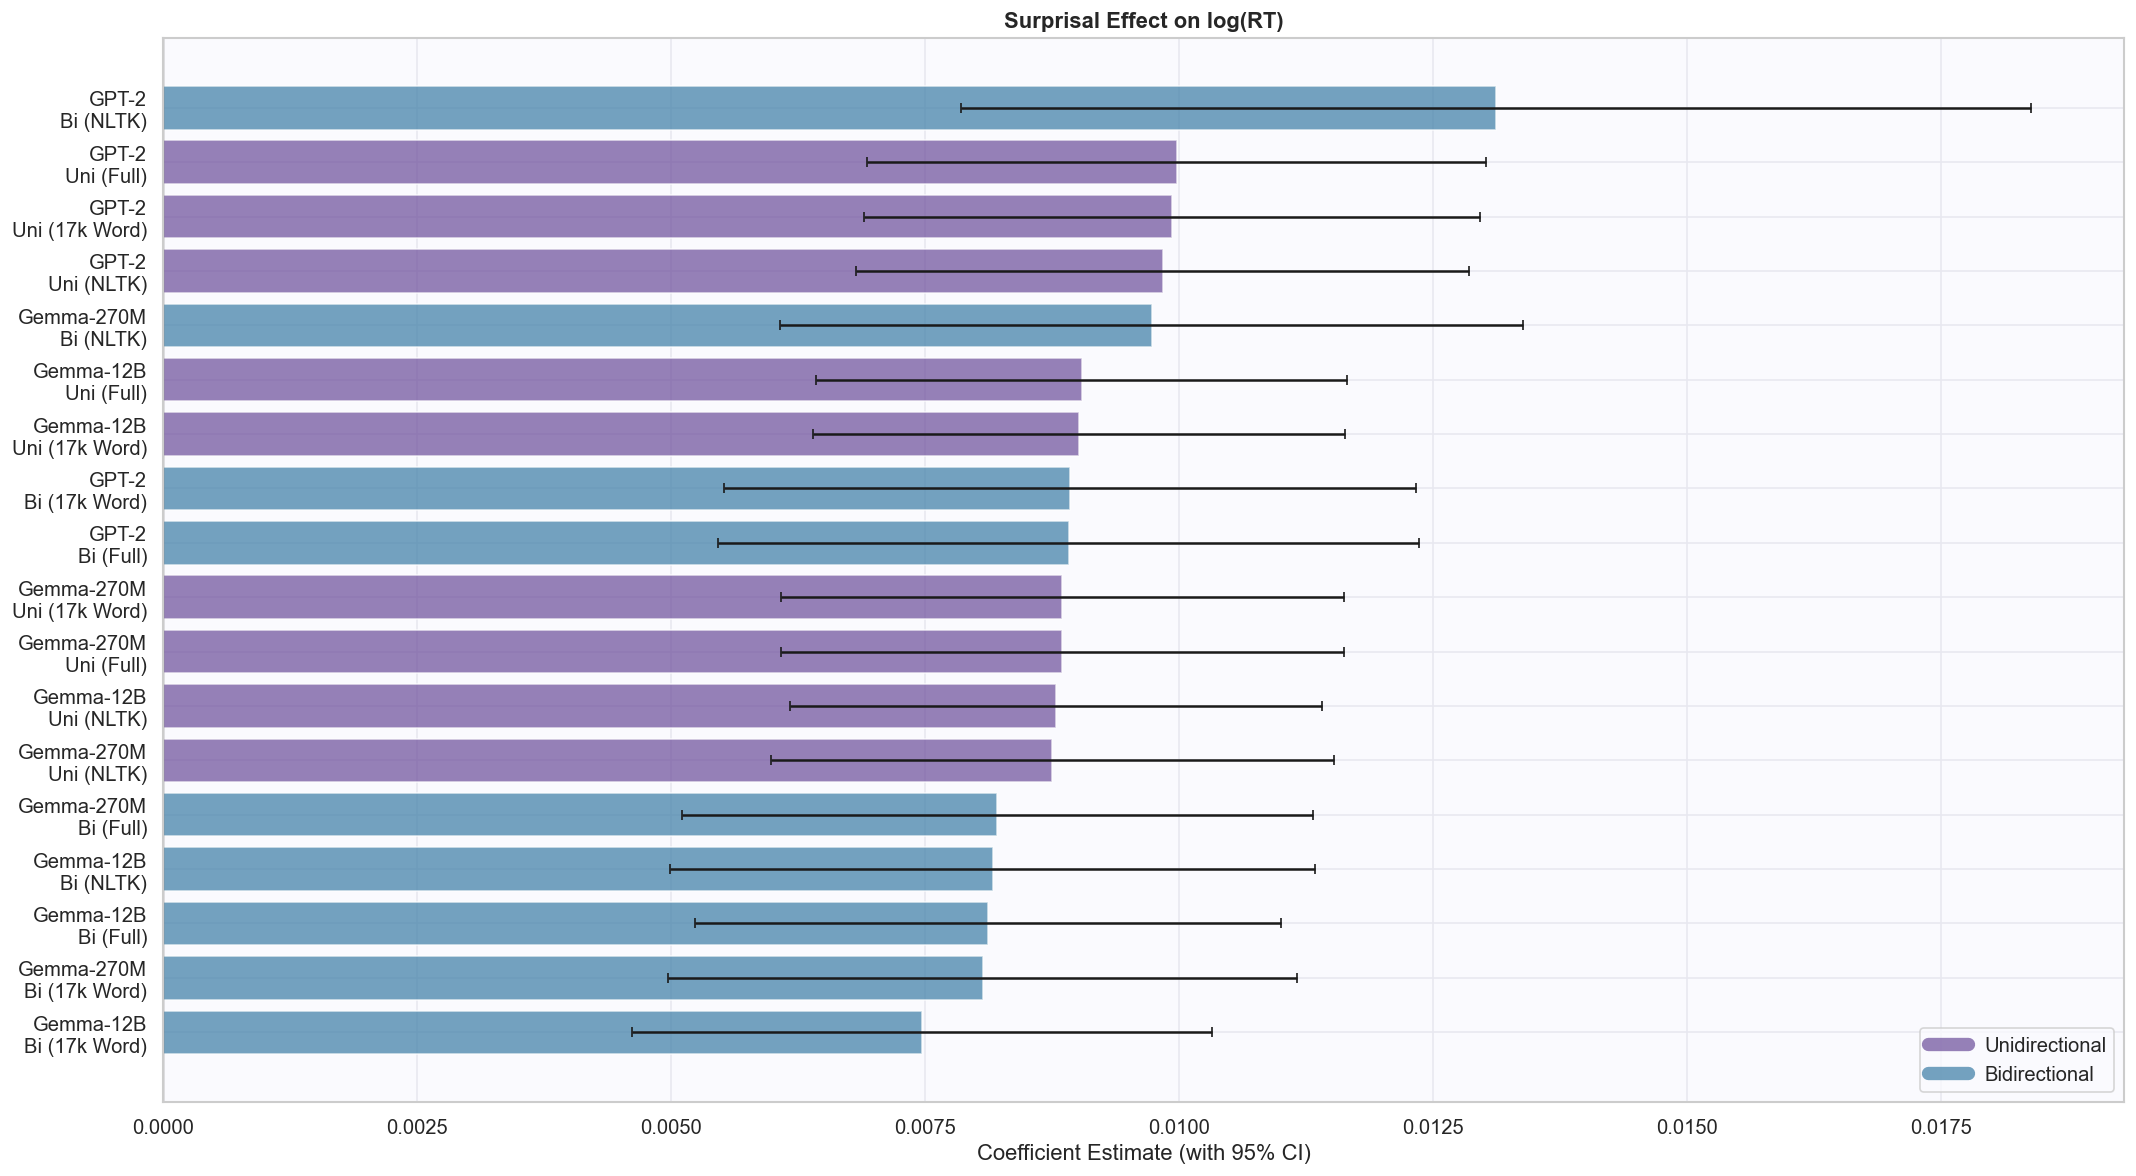

In [48]:
# Fixed Effect Sizes

if not df_fixed.empty:
    display(Markdown("### Surprisal Fixed Effect Sizes"))

    fig, ax = plt.subplots(figsize=(18, 10))

    df_fixed_plot = df_fixed.copy()
    df_fixed_plot["label"] = df_fixed_plot["Model_Base"] + "\n" + df_fixed_plot["Condition"]
    df_fixed_plot = df_fixed_plot.sort_values("Estimate")

    colors = [PURPLE_MID if "Uni" in c else BLUE_MID for c in df_fixed_plot["Condition"]]

    ax.barh(df_fixed_plot["label"], df_fixed_plot["Estimate"],
            xerr=df_fixed_plot["Std_Error"] * 1.96, color=colors,
            alpha=0.7, edgecolor="white", capsize=3)
    ax.axvline(0, color="gray", ls="-", alpha=0.3)
    ax.set_xlabel("Coefficient Estimate (with 95% CI)")
    ax.set_title("Surprisal Effect on log(RT)", fontweight="bold")

    legend_elements = [
        Line2D([0], [0], color=PURPLE_MID, lw=8, alpha=0.7, label="Unidirectional"),
        Line2D([0], [0], color=BLUE_MID, lw=8, alpha=0.7, label="Bidirectional"),
    ]
    ax.legend(handles=legend_elements)

    plt.tight_layout()
    plt.show()

In [49]:
# Summary Statistics Table

summary_rows = []
for name, df in dfs.items():
    row = {
        "Model": name,
        "Family": df["_family"].iloc[0],
        "Base": df["_base_model"].iloc[0],
        "N": len(df),
        "Uni Mean": df["uni"].mean(),
        "Bi Mean": df["bi"].mean(),
        "Bi=0": (df["bi"] == 0).sum(),
        "Bi<0": (df["bi"] < 0).sum(),
        "% Bi>Uni": f'{(df["bi"] > df["uni"]).mean():.1%}',
    }

    if "cloze" in df.columns:
        valid = df.dropna(subset=["uni", "bi", "cloze"])
        if len(valid) > 10:
            row["r(Uni,Cloze)"] = pearsonr(valid["cloze"], valid["uni"])[0]
            row["r(Bi,Cloze)"] = pearsonr(valid["cloze"], valid["bi"])[0]

    summary_rows.append(row)

summary_final = pd.DataFrame(summary_rows).set_index("Model")
display(
    summary_final.style
    .background_gradient(cmap="PuBu", subset=["Uni Mean", "Bi Mean"])
    .format({
        "Uni Mean": "{:.3f}", "Bi Mean": "{:.3f}",
        "r(Uni,Cloze)": "{:.4f}", "r(Bi,Cloze)": "{:.4f}",
    })
)

,Family,Base,N,Uni Mean,Bi Mean,Bi=0,Bi<0,% Bi>Uni,"r(Uni,Cloze)","r(Bi,Cloze)"
Model,,,,,,,,,,
GPT-2 [Token Full],Token Full,GPT-2,648,6.703,4.836,17,6,20.2%,0.6196,0.4750
Gemma-270M [Token Full],Token Full,Gemma-270M,648,5.860,4.127,14,0,21.1%,0.7428,0.5820
Gemma-12B [Token Full],Token Full,Gemma-12B,648,4.551,2.792,43,0,16.8%,0.8345,0.6404
GPT-2 [Token NLTK],Token NLTK,GPT-2,648,6.497,5.863,0,0,20.5%,0.6303,0.2927
Gemma-270M [Token NLTK],Token NLTK,Gemma-270M,648,5.646,4.167,15,0,20.5%,0.7455,0.4934
Gemma-12B [Token NLTK],Token NLTK,Gemma-12B,648,4.387,2.822,61,8,20.4%,0.8339,0.5764
GPT-2 [Word 17k],Word 17k,GPT-2,648,6.750,5.014,0,0,14.4%,0.6256,0.5137
Gemma-270M [Word 17k],Word 17k,Gemma-270M,648,5.860,3.956,0,0,17.1%,0.7428,0.5910
Gemma-12B [Word 17k],Word 17k,Gemma-12B,648,4.587,2.639,0,0,13.7%,0.8288,0.6433
